# 🛒 Indian E-Commerce Customer Behavior Analysis

**What is this notebook about?**
We have data from an Indian e-commerce website — 25,000 customer visits from 2024.
We want to understand:
- Who is buying?
- What products sell the most?
- Why do customers leave without buying?

**How to use this notebook:**
Just run each cell one by one (Shift + Enter). Each section has a simple explanation before the code.

## Step 1: Import Libraries

Before doing anything, we need to load the tools (libraries) we'll use.
- `pandas` → for working with tables/data
- `numpy` → for numbers and calculations
- `matplotlib` and `seaborn` → for making charts

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

## Step 2: Load the Data

We load our CSV file into a **DataFrame** (think of it as an Excel table in Python).
Then we take a quick look at the first 5 rows.

In [40]:
df = pd.read_csv('/content/Ecommerce.csv')

## Step 3: Understand the Data

Let's check:
1. What columns do we have and what type of data is in them?
2. Are there any missing values?

In [41]:
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [42]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 25000
Columns: 29


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [44]:
# Check for missing values in each column
missing = df.isnull().sum()

In [45]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


## Step 4: Clean the Data

**Why do we clean data?**
Some columns are not useful for our analysis. We remove them to keep things simple.
We also fix the date column so Python understands it as a date (not just text).

**Columns we're removing:**
- `session_id` — just a row number, not useful
- `revenue_normalized` — same info as revenue, just scaled differently
- `review_text` — stored as a number code, unclear meaning
- `visit_day` — we already have month and season, day is too detailed

In [46]:
df.drop(['session_id', 'revenue_normalized', 'review_text', 'visit_day', 'visit_weekday'], axis=1, inplace=True)

In [47]:
df.shape

(25000, 24)

In [48]:
df['visit_date'] = pd.to_datetime(df['visit_date'], dayfirst=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              25000 non-null  int64         
 1   visit_date               25000 non-null  datetime64[ns]
 2   device_type              25000 non-null  int64         
 3   user_type                25000 non-null  int64         
 4   marketing_channel        25000 non-null  int64         
 5   product_id               25000 non-null  int64         
 6   product_category         25000 non-null  int64         
 7   unit_price               25000 non-null  float64       
 8   quantity                 25000 non-null  int64         
 9   discount_percent         25000 non-null  int64         
 10  discount_amount          25000 non-null  float64       
 11  revenue                  25000 non-null  float64       
 12  pages_viewed             25000 n

## Step 5: Make Column Values Readable

Right now, columns like `device_type` store numbers (0, 1, 2) instead of real names.
We'll add new columns with the actual labels so charts are easier to understand.

| Column | 0 | 1 | 2 |
|--------|---|---|---|
| device_type | Desktop | Mobile | Tablet |
| user_type | New User | Returning User | — |

In [50]:
device_map = {
    0: "Desktop",
    1: "Mobile",
    2: "Tablet"
}

df["device_name"] = df["device_type"].map(device_map)

In [51]:
user_map = {
    0: "New User",
    1: "Returning User"
}

df["user_type_name"] = df["user_type"].map(user_map)

In [52]:
channel_map = {
    0: "Organic Search",
    1: "Paid Search",
    2: "Email",
    3: "Social Media",
    4: "Referral",
    5: "Direct"
}

df["channel_name"] = df["marketing_channel"].map(channel_map)

In [53]:
category_map = {
    0: "Electronics",
    1: "Clothing",
    2: "Home & Kitchen",
    3: "Sports",
    4: "Books",
    5: "Beauty",
    6: "Toys",
    7: "Grocery"
}

df["category_name"] = df["product_category"].map(category_map)

In [54]:
payment_map = {
    0: "Credit Card",
    1: "Debit Card",
    2: "UPI",
    3: "Net Banking",
    4: "Wallet",
    5: "COD"
}

df["payment_name"] = df["payment_method"].map(payment_map)

In [55]:
season_map = {
    0: "Winter",
    1: "Spring",
    2: "Summer",
    3: "Autumn"
}

df["season_name"] = df["visit_season"].map(season_map)

In [56]:
df.head()

,customer_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,...,visit_month,visit_season,session_duration_bucket,location,device_name,user_type_name,channel_name,category_name,payment_name,season_name
0,1803,2024-11-28,2,1,2,894,6,651.57,1,20,...,11,0,Long,209,Tablet,Returning User,Email,Toys,Debit Card,Winter
1,7964,2024-09-25,2,0,4,844,2,945.27,4,15,...,9,0,Long,213,Tablet,New User,Referral,Home & Kitchen,UPI,Winter
2,6890,2024-05-31,1,1,0,865,0,400.44,4,0,...,5,1,Short,10,Mobile,Returning User,Organic Search,Electronics,UPI,Spring
3,4949,2024-01-30,1,0,2,851,3,1268.54,2,5,...,1,3,Very Long,46,Mobile,New User,Email,Sports,Debit Card,Autumn
4,4896,2024-02-25,1,1,5,794,3,880.81,3,0,...,2,3,Very Short,118,Mobile,Returning User,Direct,Sports,Debit Card,Autumn


## Step 6: Basic Statistics

Let's look at some quick numbers to get a feel for the data.

In [57]:
df.describe()

,customer_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,...,time_on_site_sec,added_to_cart,purchased,cart_abandoned,rating,review_helpful_votes,payment_method,visit_month,visit_season,location
count,25000.000000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.000000,25000.00000,25000.000000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.00000
mean,5479.930600,2024-07-01 08:44:02.688000,0.705040,0.551280,2.514040,449.107000,3.495240,782.319010,2.489040,8.99880,...,903.262920,0.64468,0.224640,0.420040,3.94800,5.52080,2.483160,6.510520,1.504400,111.70692
min,1000.000000,2024-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,50.050000,1.000000,0.00000,...,10.000000,0.00000,0.000000,0.000000,1.00000,0.00000,0.000000,1.000000,0.000000,0.00000
25%,3234.000000,2024-03-31 00:00:00,0.000000,0.000000,1.000000,225.000000,2.000000,395.222500,1.000000,0.00000,...,453.000000,0.00000,0.000000,0.000000,4.00000,0.00000,1.000000,3.000000,1.000000,55.00000
50%,5482.000000,2024-07-02 00:00:00,1.000000,1.000000,2.000000,448.000000,4.000000,691.725000,2.000000,10.00000,...,903.000000,1.00000,0.000000,0.000000,4.00000,0.00000,2.000000,7.000000,2.000000,111.00000
75%,7715.000000,2024-10-01 00:00:00,1.000000,1.000000,4.000000,675.000000,5.000000,1096.842500,3.000000,15.00000,...,1355.000000,1.00000,0.000000,1.000000,4.00000,0.00000,4.000000,10.000000,3.000000,169.00000
max,9998.000000,2024-12-30 00:00:00,2.000000,1.000000,5.000000,898.000000,7.000000,1999.830000,4.000000,30.00000,...,1799.000000,1.00000,1.000000,1.000000,5.00000,49.00000,5.000000,12.000000,3.000000,224.00000
std,2593.544596,NaN,0.639543,0.497373,1.704934,259.513787,2.285053,476.612168,1.114563,9.26364,...,518.676202,0.47862,0.417353,0.493575,0.54047,12.33629,1.709501,3.457925,1.117475,65.07079


In [58]:
# Total revenue
total_revenue = df["revenue"].sum()

# Purchase rate
purchase_rate = df["purchased"].mean() * 100

# Add to cart rate
cart_rate = df["added_to_cart"].mean() * 100

# Cart abandonment rate
abandon_rate = df["cart_abandoned"].mean() * 100

# Average order value (only for purchased orders)
avg_order_value = df[df["purchased"] == 1]["revenue"].mean()


print("Total Sessions:", len(df))
print("Total Revenue:", total_revenue)
print("Add to Cart Rate:", cart_rate)
print("Purchase Rate:", purchase_rate)
print("Cart Abandonment Rate:", abandon_rate)
print("Average Order Value:", avg_order_value)

Total Sessions: 25000
Total Revenue: 10116169.06
Add to Cart Rate: 64.468
Purchase Rate: 22.464000000000002
Cart Abandonment Rate: 42.004000000000005
Average Order Value: 1801.3121545584047


## Step 7: Visualizations (Charts)

Now the fun part! We'll make charts to find patterns in the data.
Each chart answers a specific business question.

/tmp/ipykernel_446/4013331786.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Stage", y="Users", data=funnel_df, palette="viridis")


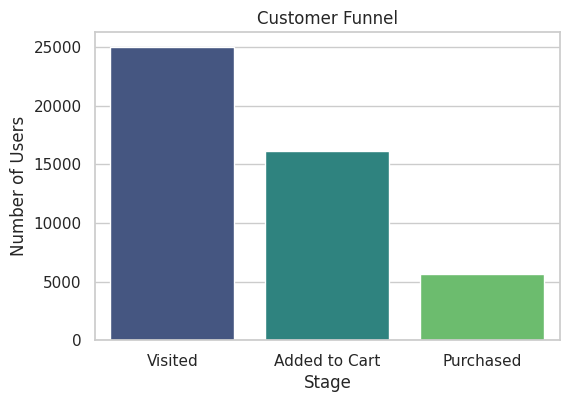

In [59]:
visited = len(df)
added_cart = df["added_to_cart"].sum()
purchased = df["purchased"].sum()

stages = ["Visited", "Added to Cart", "Purchased"]
values = [visited, added_cart, purchased]

funnel_df = pd.DataFrame({
    "Stage": stages,
    "Users": values
})

plt.figure(figsize=(6,4))

sns.barplot(x="Stage", y="Users", data=funnel_df, palette="viridis")

plt.title("Customer Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Users")

plt.show()

/tmp/ipykernel_446/11330275.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


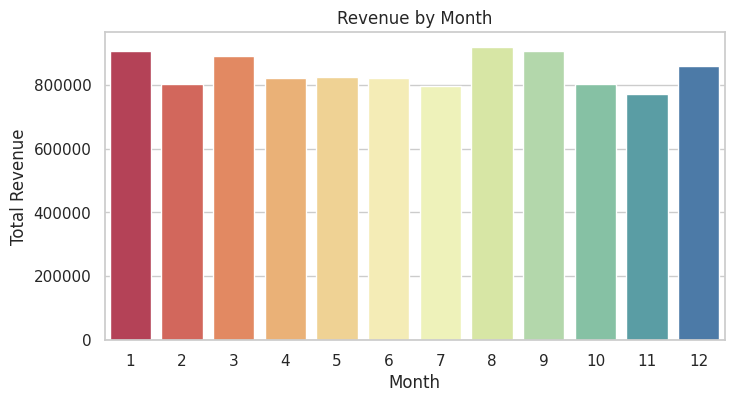

In [60]:
monthly_revenue = df.groupby("visit_month")["revenue"].sum()

plt.figure(figsize=(8,4))

sns.barplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    palette="Spectral"
)

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.show()

/tmp/ipykernel_446/1982963553.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


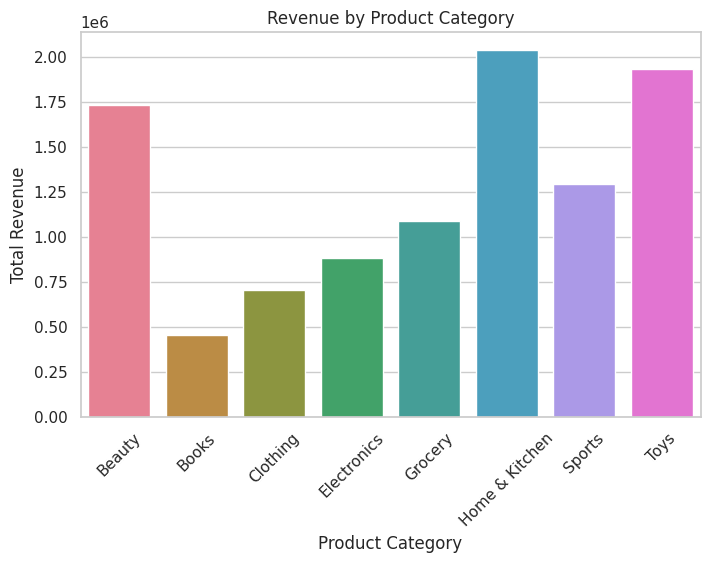

In [61]:
cat_revenue = df.groupby("category_name")["revenue"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=cat_revenue.index,
    y=cat_revenue.values,
    palette="husl"   # colorful palette
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

/tmp/ipykernel_446/25783076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


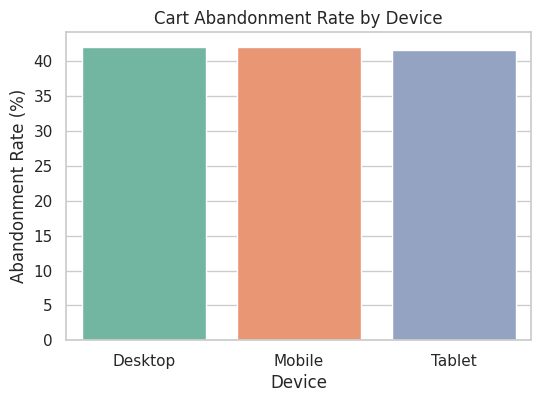

In [62]:
abandon_by_device = df.groupby("device_name")["cart_abandoned"].mean() * 100

plt.figure(figsize=(6,4))

sns.barplot(
    x=abandon_by_device.index,
    y=abandon_by_device.values,
    palette="Set2"
)

plt.title("Cart Abandonment Rate by Device")
plt.xlabel("Device")
plt.ylabel("Abandonment Rate (%)")

plt.show()

/tmp/ipykernel_446/3007121521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


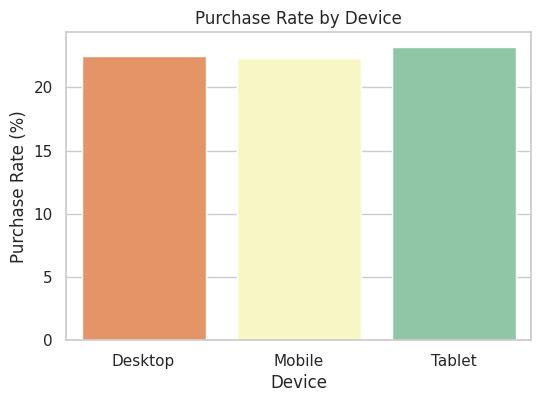

In [63]:
purchase_by_device = df.groupby("device_name")["purchased"].mean() * 100

plt.figure(figsize=(6,4))

sns.barplot(
    x=purchase_by_device.index,
    y=purchase_by_device.values,
    palette="Spectral"
)

plt.title("Purchase Rate by Device")
plt.xlabel("Device")
plt.ylabel("Purchase Rate (%)")

plt.show()

/tmp/ipykernel_446/1849057568.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


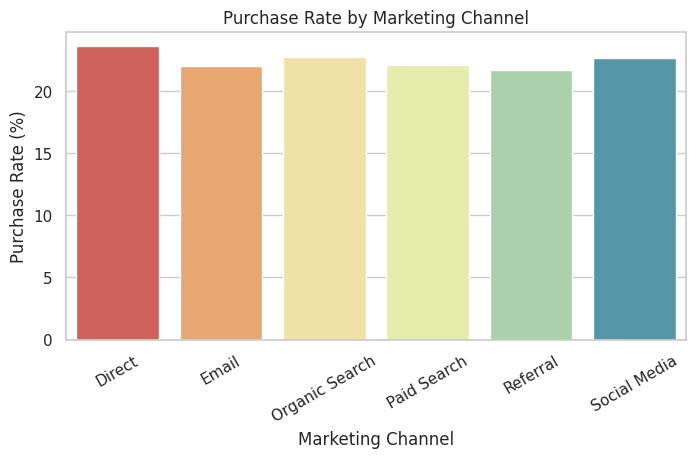

In [64]:
channel_purchase = df.groupby("channel_name")["purchased"].mean() * 100

plt.figure(figsize=(8,4))

sns.barplot(
    x=channel_purchase.index,
    y=channel_purchase.values,
    palette="Spectral"
)

plt.title("Purchase Rate by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Purchase Rate (%)")

plt.xticks(rotation=30)

plt.show()

/tmp/ipykernel_446/938781865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


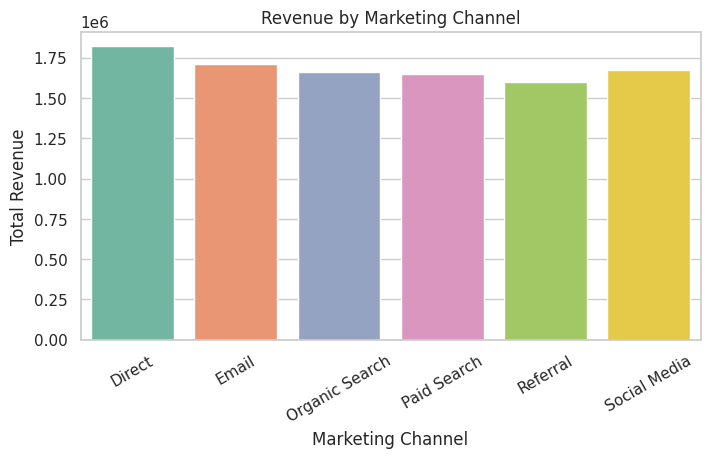

In [65]:
channel_revenue = df.groupby("channel_name")["revenue"].sum()

plt.figure(figsize=(8,4))

sns.barplot(
    x=channel_revenue.index,
    y=channel_revenue.values,
    palette="Set2"
)

plt.title("Revenue by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.show()

/tmp/ipykernel_446/682892304.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


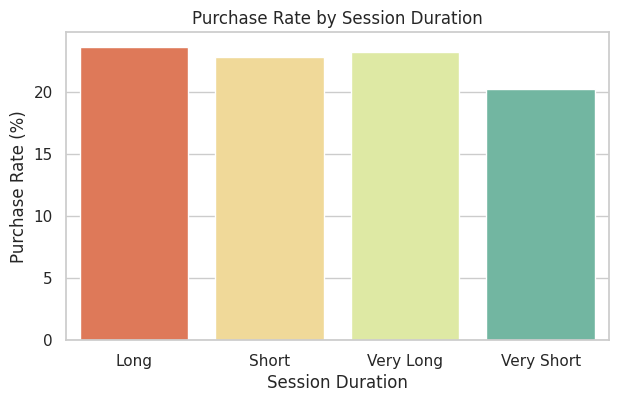

In [66]:
dur_purchase = df.groupby("session_duration_bucket")["purchased"].mean() * 100

plt.figure(figsize=(7,4))

sns.barplot(
    x=dur_purchase.index,
    y=dur_purchase.values,
    palette="Spectral"
)

plt.title("Purchase Rate by Session Duration")
plt.xlabel("Session Duration")
plt.ylabel("Purchase Rate (%)")

plt.show()

/tmp/ipykernel_446/2503706520.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


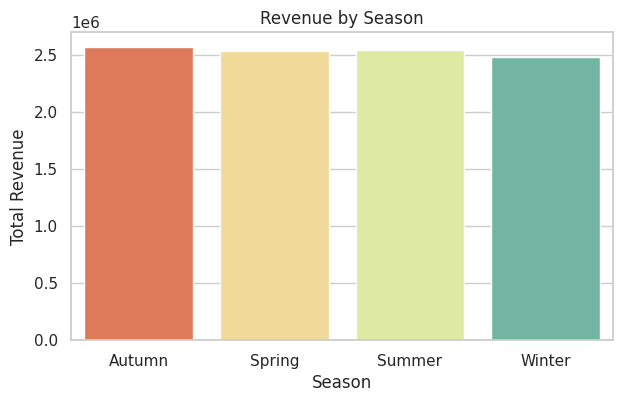

In [67]:
season_revenue = df.groupby("season_name")["revenue"].sum()

plt.figure(figsize=(7,4))

sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values,
    palette="Spectral"
)

plt.title("Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Total Revenue")

plt.show()

/tmp/ipykernel_446/559094707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


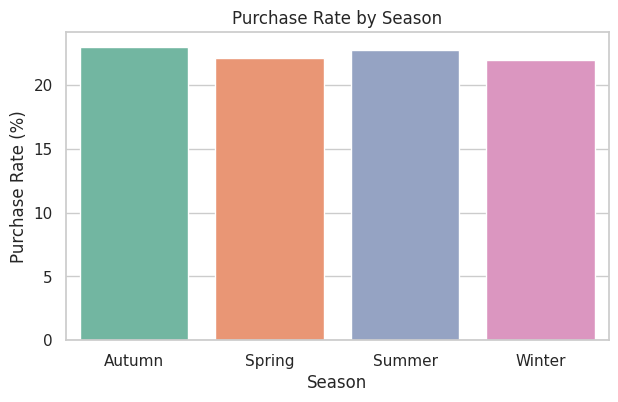

In [68]:
season_conversion = df.groupby("season_name")["purchased"].mean() * 100

plt.figure(figsize=(7,4))

sns.barplot(
    x=season_conversion.index,
    y=season_conversion.values,
    palette="Set2"
)

plt.title("Purchase Rate by Season")
plt.xlabel("Season")
plt.ylabel("Purchase Rate (%)")

plt.show()

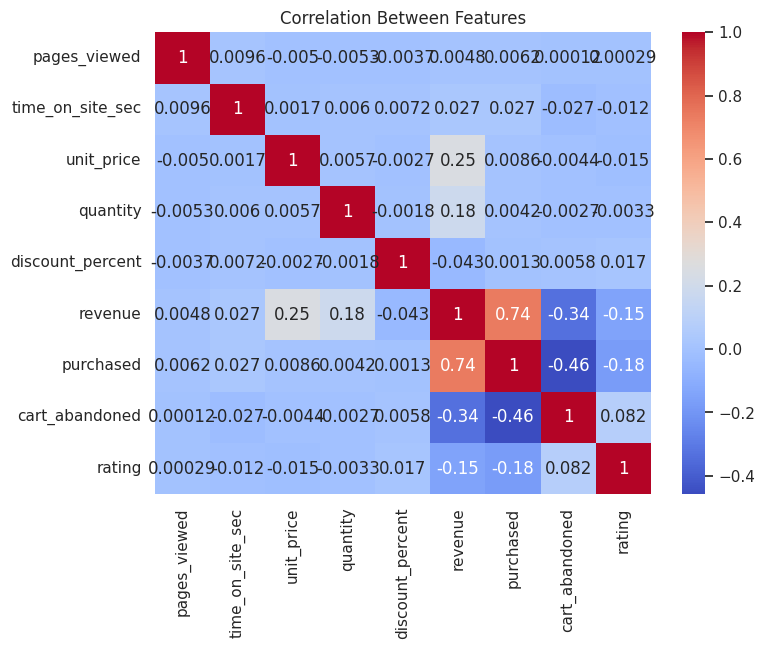

In [69]:
numeric_cols = [
    'pages_viewed', 'time_on_site_sec', 'unit_price',
    'quantity', 'discount_percent', 'revenue',
    'purchased', 'cart_abandoned', 'rating'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Features")

plt.show()

## Step 8: Summary of Findings 📋

Here's what we discovered from the data:

---

### 🔻 Conversion Funnel
- **64.5%** of visitors add items to their cart
- Only **22.5%** actually complete a purchase
- **42%** of carts are abandoned — this is the biggest problem area

---

### 📅 Monthly Trends
- **August and September** are the highest revenue months
- **November** is surprisingly low (worth investigating)
- Revenue is fairly stable (~₹0.8–0.9M per month)

---

### 📦 Product Categories
- **Home & Kitchen** is the top revenue category
- **Books** generates the least revenue

---

### 📱 Device Type
- Purchase rates are almost the same across Desktop, Mobile, and Tablet (~22–23%)
- The website works equally well on all devices ✅

---

### 📣 Marketing Channels
- All channels perform similarly in terms of purchase rate
- **Direct** traffic has slightly the best conversion — existing customers come back

---

### ⏱️ Session Duration
- Longer sessions = slightly higher purchase rate
- Keeping users engaged on the site is important

---

### 🎯 Recommendations
1. **Fix cart abandonment** — send reminder emails or show exit-intent popups
2. **Boost November sales** — run special campaigns during the festive season
3. **Invest in retention** — returning customers are more likely to buy